# Load Forecasting for Smart Grids — Sample Project

This notebook demonstrates a complete **hour-ahead load forecasting** workflow for a smart grid scenario.

The notebook uses two sample datasets:
- `sample_load_data.csv`
- `sample_weather_data.csv`

The main goal is to predict:

**electricity load for the next hour**

using:
- historical load values
- weather variables
- time-based features

The workflow is beginner-friendly, but it follows the same general stages used in real projects:
1. import libraries  
2. load and inspect data  
3. clean and align the datasets  
4. merge load and weather data  
5. create forecasting features  
6. train a baseline and a machine learning model  
7. evaluate and visualize the results

## Step 1: Import the Python libraries

In this first step, the Python libraries that will be used throughout the notebook are imported.

- `pandas` is used for working with tables and time series data.
- `numpy` is used for numerical operations.
- `matplotlib` is used for plotting.
- `RandomForestRegressor` is used as the forecasting model.
- the metric functions are used to measure model accuracy.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## Step 2: Load the sample datasets

In this step, the load dataset and the weather dataset are read from CSV files.

These sample datasets were prepared for this project and already contain:
- hourly timestamps
- realistic load patterns
- realistic weather patterns
- a small number of missing values and duplicate timestamps for cleaning practice

In [3]:
BASE_URL = "https://raw.githubusercontent.com/tskaneva/bip_2026_big_data_and_ai_in_res/main/data"

load_df = pd.read_csv(f"{BASE_URL}/sample_load_data.csv")
weather_df = pd.read_csv(f"{BASE_URL}/sample_weather_data.csv")

## Step 3: Display the first rows and the structure of both datasets

In this step, the first few rows and general information about each dataset are displayed.

This is useful because it helps confirm:
- the files were loaded correctly
- the expected columns exist
- the data types are appropriate

In [4]:
print("LOAD DATA")
display(load_df.head())
print(load_df.info())

print("\nWEATHER DATA")
display(weather_df.head())
print(weather_df.info())

LOAD DATA


,timestamp,load_kwh
0,2024-10-28 14:00:00,34.675
1,2024-09-07 12:00:00,29.256
2,2024-10-16 21:00:00,33.395
3,2024-10-06 08:00:00,31.207
4,2024-09-07 14:00:00,27.683


<class 'pandas.DataFrame'>
RangeIndex: 8792 entries, 0 to 8791
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   timestamp  8792 non-null   str    
 1   load_kwh   8751 non-null   float64
dtypes: float64(1), str(1)
memory usage: 137.5 KB
None

WEATHER DATA


,timestamp,temperature,humidity,wind_speed
0,2024-04-18 00:00:00,19.668,53.786,3.740
1,2024-01-12 09:00:00,-2.897,86.082,1.800
2,2024-01-26 22:00:00,9.235,65.300,4.206
3,2024-04-16 14:00:00,17.969,56.356,7.096
4,2024-07-29 10:00:00,19.147,55.474,NaN


<class 'pandas.DataFrame'>
RangeIndex: 8792 entries, 0 to 8791
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   timestamp    8792 non-null   str    
 1   temperature  8737 non-null   float64
 2   humidity     8737 non-null   float64
 3   wind_speed   8737 non-null   float64
dtypes: float64(3), str(1)
memory usage: 274.9 KB
None


## Step 4: Convert timestamps to datetime format

In this step, the timestamp columns are converted to datetime format.

This is necessary because time-based operations such as:
- sorting
- resampling
- merging
- extracting hour and day information

all require proper datetime values.

In [5]:
load_df["timestamp"] = pd.to_datetime(load_df["timestamp"])
weather_df["timestamp"] = pd.to_datetime(weather_df["timestamp"])

## Step 5: Sort the data chronologically

In this step, both datasets are sorted by time.

Time series forecasting must always respect the order of time, so this operation is important before feature engineering and model training.

In [6]:
load_df = load_df.sort_values("timestamp").reset_index(drop=True)
weather_df = weather_df.sort_values("timestamp").reset_index(drop=True)

## Step 6: Remove duplicate timestamps

In this step, duplicate timestamps are removed.

A duplicated timestamp can cause:
- repeated measurements
- incorrect merges
- distorted forecasts

Only the first occurrence of each timestamp is kept.

In [7]:
print("Load duplicates before cleaning:", load_df.duplicated(subset="timestamp").sum())
print("Weather duplicates before cleaning:", weather_df.duplicated(subset="timestamp").sum())

load_df = load_df.drop_duplicates(subset="timestamp")
weather_df = weather_df.drop_duplicates(subset="timestamp")

print("Load duplicates after cleaning:", load_df.duplicated(subset="timestamp").sum())
print("Weather duplicates after cleaning:", weather_df.duplicated(subset="timestamp").sum())

Load duplicates before cleaning: 8
Weather duplicates before cleaning: 8
Load duplicates after cleaning: 0
Weather duplicates after cleaning: 0


## Step 7: Check missing values before merging

In this step, missing values are counted in both datasets.

Missing values are common in real energy datasets because sensors, meters, or communication systems may occasionally fail.

In [8]:
print("Missing values in load data:")
print(load_df.isna().sum())

print("\nMissing values in weather data:")
print(weather_df.isna().sum())

Missing values in load data:
timestamp     0
load_kwh     40
dtype: int64

Missing values in weather data:
timestamp       0
temperature    55
humidity       55
wind_speed     55
dtype: int64


## Step 8: Set the timestamp as the index

In this step, the timestamp column becomes the index of each DataFrame.

This makes time-based operations more convenient, especially resampling and joining.

In [9]:
load_df = load_df.set_index("timestamp")
weather_df = weather_df.set_index("timestamp")

## Step 9: Resample both datasets to hourly frequency

In this step, the two datasets are resampled to one-hour intervals.

The target of this project is **hour-ahead forecasting**, so hourly data is the most suitable format.

The mean is used during resampling because it is a practical aggregation choice for this example.

In [10]:
load_df = load_df.resample("h").mean()
weather_df = weather_df.resample("h").mean()

## Step 10: Merge the load data and the weather data

In this step, the two datasets are merged into one table using the timestamp index.

The result is a single dataset where each row contains:
- load
- temperature
- humidity
- wind speed

In [11]:
df = load_df.join(weather_df, how="inner")
display(df.head())
print("Merged dataset shape:", df.shape)

,load_kwh,temperature,humidity,wind_speed
timestamp,,,,
2024-01-01 00:00:00,36.593,3.160,70.852,2.358
2024-01-01 01:00:00,36.845,1.052,78.498,2.174
2024-01-01 02:00:00,35.840,1.432,82.185,5.112
2024-01-01 03:00:00,36.406,1.972,80.542,3.040
2024-01-01 04:00:00,38.908,-2.156,86.385,3.315


Merged dataset shape: (8784, 4)


## Step 11: Check and fill missing values after merging

In this step, missing values are checked again after the merge.

Forward fill and backward fill are then used:
- forward fill propagates the previous valid value
- backward fill is used only if missing values remain at the beginning

This is a practical choice for time series data.

In [12]:
print("Missing values before filling:")
print(df.isna().sum())

df = df.ffill().bfill()

print("\nMissing values after filling:")
print(df.isna().sum())

Missing values before filling:
load_kwh       40
temperature    55
humidity       55
wind_speed     55
dtype: int64

Missing values after filling:
load_kwh       0
temperature    0
humidity       0
wind_speed     0
dtype: int64


## Step 12: Visualize the load series

In this step, the load values are plotted over time.

This plot helps reveal:
- daily consumption cycles
- seasonal changes
- unusual peaks or dips

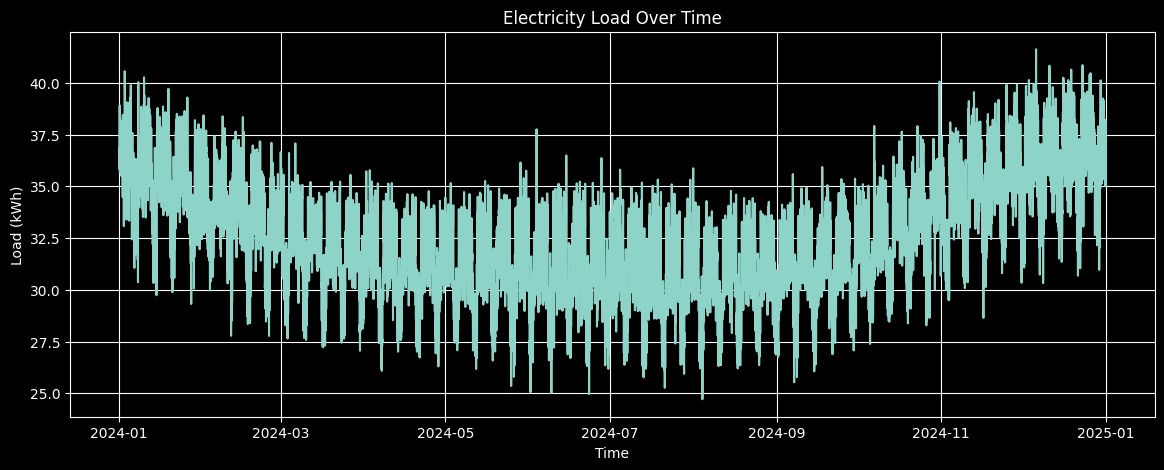

In [13]:
plt.figure(figsize=(14, 5))
plt.plot(df.index, df["load_kwh"])
plt.title("Electricity Load Over Time")
plt.xlabel("Time")
plt.ylabel("Load (kWh)")
plt.grid(True)
plt.show()

## Step 13: Create calendar-based features

In this step, time-related predictors are extracted from the timestamp.

These features are important because energy demand often depends on:
- hour of day
- day of week
- month
- whether the day is a weekend

In [14]:
df["hour"] = df.index.hour
df["day_of_week"] = df.index.dayofweek
df["month"] = df.index.month
df["is_weekend"] = (df["day_of_week"] >= 5).astype(int)

display(df[["load_kwh", "hour", "day_of_week", "month", "is_weekend"]].head())

,load_kwh,hour,day_of_week,month,is_weekend
timestamp,,,,,
2024-01-01 00:00:00,36.593,0,0,1,0
2024-01-01 01:00:00,36.845,1,0,1,0
2024-01-01 02:00:00,35.840,2,0,1,0
2024-01-01 03:00:00,36.406,3,0,1,0
2024-01-01 04:00:00,38.908,4,0,1,0


## Step 14: Create cyclical time features

In this step, cyclical features are created using sine and cosine transformations.

This is useful because time behaves cyclically:
- hour 23 and hour 0 are close in reality
- day 6 and day 0 are also close in a weekly cycle

A sine/cosine representation helps the model understand this cyclic structure better than raw integers alone.

In [15]:
df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)

df["dow_sin"] = np.sin(2 * np.pi * df["day_of_week"] / 7)
df["dow_cos"] = np.cos(2 * np.pi * df["day_of_week"] / 7)

display(df[["hour", "hour_sin", "hour_cos", "day_of_week", "dow_sin", "dow_cos"]].head())

,hour,hour_sin,hour_cos,day_of_week,dow_sin,dow_cos
timestamp,,,,,,
2024-01-01 00:00:00,0,0.000000,1.000000,0,0.0,1.0
2024-01-01 01:00:00,1,0.258819,0.965926,0,0.0,1.0
2024-01-01 02:00:00,2,0.500000,0.866025,0,0.0,1.0
2024-01-01 03:00:00,3,0.707107,0.707107,0,0.0,1.0
2024-01-01 04:00:00,4,0.866025,0.500000,0,0.0,1.0


## Step 15: Create lag features from previous load values

In this step, lag features are created from historical load values.

These are among the most useful predictors in load forecasting because the recent past often strongly influences the near future.

The selected lag values are:
- `lag_1`: previous hour
- `lag_24`: same hour on the previous day
- `lag_168`: same hour one week earlier

In [16]:
df["lag_1"] = df["load_kwh"].shift(1)
df["lag_24"] = df["load_kwh"].shift(24)
df["lag_168"] = df["load_kwh"].shift(168)

display(df[["load_kwh", "lag_1", "lag_24", "lag_168"]].head(30))

,load_kwh,lag_1,lag_24,lag_168
timestamp,,,,
2024-01-01 00:00:00,36.593,NaN,NaN,NaN
2024-01-01 01:00:00,36.845,36.593,NaN,NaN
2024-01-01 02:00:00,35.840,36.845,NaN,NaN
2024-01-01 03:00:00,36.406,35.840,NaN,NaN
2024-01-01 04:00:00,38.908,36.406,NaN,NaN
2024-01-01 05:00:00,38.285,38.908,NaN,NaN
2024-01-01 06:00:00,35.673,38.285,NaN,NaN
2024-01-01 07:00:00,37.720,35.673,NaN,NaN
2024-01-01 08:00:00,37.543,37.720,NaN,NaN


## Step 16: Create rolling average features

In this step, rolling means are calculated.

These features summarize the recent behavior of the load:
- the last 24 hours
- the last 168 hours

The shift is applied first so that the current target value is not accidentally included.

In [17]:
df["rolling_mean_24"] = df["load_kwh"].shift(1).rolling(window=24).mean()
df["rolling_mean_168"] = df["load_kwh"].shift(1).rolling(window=168).mean()

## Step 17: Create the target variable

In this step, the target variable is defined as the load value one hour ahead.

This means the model will learn to predict:

**next hour load**

using only current and past information.

In [18]:
df["target_load_next_hour"] = df["load_kwh"].shift(-1)

## Step 18: Remove rows with missing values caused by shifting

In this step, rows containing missing values are removed.

This is necessary because:
- lag features create empty rows at the beginning
- the target shift creates an empty row at the end

In [19]:
df = df.dropna()
print("Final dataset shape:", df.shape)
display(df.head())

Final dataset shape: (8615, 18)


,load_kwh,temperature,humidity,wind_speed,hour,day_of_week,month,is_weekend,hour_sin,hour_cos,dow_sin,dow_cos,lag_1,lag_24,lag_168,rolling_mean_24,rolling_mean_168,target_load_next_hour
timestamp,,,,,,,,,,,,,,,,,,
2024-01-08 00:00:00,36.577,2.211,71.430,5.149,0,0,1,0,0.000000,1.000000,0.0,1.0,30.369,34.217,36.593,33.548708,35.826554,37.727
2024-01-08 01:00:00,37.727,0.331,74.928,4.145,1,0,1,0,0.258819,0.965926,0.0,1.0,36.577,32.642,36.845,33.647042,35.826458,40.039
2024-01-08 02:00:00,40.039,-0.948,78.055,3.784,2,0,1,0,0.500000,0.866025,0.0,1.0,37.727,34.407,35.840,33.858917,35.831708,38.316
2024-01-08 03:00:00,38.316,-1.851,85.458,3.227,3,0,1,0,0.707107,0.707107,0.0,1.0,40.039,36.331,36.406,34.093583,35.856702,37.687
2024-01-08 04:00:00,37.687,-1.486,78.532,5.499,4,0,1,0,0.866025,0.500000,0.0,1.0,38.316,32.247,38.908,34.176292,35.868071,37.229


## Step 19: Define input features and target

In this step, the feature columns and the target variable are separated.

The selected feature set includes:
- weather variables
- calendar variables
- cyclical variables
- lag values
- rolling averages

In [20]:
feature_columns = [
    "temperature",
    "humidity",
    "wind_speed",
    "hour",
    "day_of_week",
    "month",
    "is_weekend",
    "hour_sin",
    "hour_cos",
    "dow_sin",
    "dow_cos",
    "lag_1",
    "lag_24",
    "lag_168",
    "rolling_mean_24",
    "rolling_mean_168"
]

X = df[feature_columns]
y = df["target_load_next_hour"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (8615, 16)
y shape: (8615,)


## Step 20: Split the dataset chronologically

In this step, the dataset is split into:
- training set
- validation set
- test set

A chronological split is used because this is time series forecasting. Random shuffling would incorrectly mix future information into the past.

The proportions used are:
- 70% training
- 15% validation
- 15% test

In [21]:
n = len(df)

train_end = int(n * 0.70)
val_end = int(n * 0.85)

X_train = X.iloc[:train_end]
y_train = y.iloc[:train_end]

X_val = X.iloc[train_end:val_end]
y_val = y.iloc[train_end:val_end]

X_test = X.iloc[val_end:]
y_test = y.iloc[val_end:]

print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)
print("Test shape:", X_test.shape)

Train shape: (6030, 16)
Validation shape: (1292, 16)
Test shape: (1293, 16)


## Step 21: Create a baseline forecast

In this step, a simple baseline is created.

A common short-term load forecasting baseline is:

**next hour load ≈ current hour load**

This baseline is useful because it shows whether the machine learning model actually improves the forecast.

In [22]:
baseline_val_pred = X_val["lag_1"]
baseline_test_pred = X_test["lag_1"]

## Step 22: Define an evaluation function

In this step, a helper function is created to evaluate predictions.

The following metrics are used:
- `MAE`: mean absolute error
- `RMSE`: root mean squared error
- `R²`: coefficient of determination

In [23]:
def evaluate_model(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    print(model_name)
    print(f"MAE  : {mae:.4f}")
    print(f"RMSE : {rmse:.4f}")
    print(f"R²   : {r2:.4f}")
    print("-" * 30)

## Step 23: Evaluate the baseline forecast

In this step, the baseline predictions are evaluated on the validation set and the test set.

In [24]:
evaluate_model(y_val, baseline_val_pred, "Baseline Validation Results")
evaluate_model(y_test, baseline_test_pred, "Baseline Test Results")

Baseline Validation Results
MAE  : 1.2851
RMSE : 1.6663
R²   : 0.4026
------------------------------
Baseline Test Results
MAE  : 1.4455
RMSE : 1.8267
R²   : 0.2017
------------------------------


## Step 24: Train a Random Forest forecasting model

In this step, a `RandomForestRegressor` model is trained.

This model is a good choice for a beginner-friendly project because:
- it can model nonlinear relationships
- it works well with mixed feature types
- it requires relatively little preprocessing

The selected parameters are practical starting values:
- `n_estimators=200` means 200 trees are created
- `max_depth=12` limits tree depth and helps reduce overfitting
- `random_state=42` makes the results reproducible
- `n_jobs=-1` uses all available CPU cores

In [25]:
model = RandomForestRegressor(
    n_estimators=200,
    max_depth=12,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",12
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

## Step 25: Make predictions with the trained model

In this step, the trained model predicts the load values for the validation and test sets.

In [26]:
val_pred = model.predict(X_val)
test_pred = model.predict(X_test)

## Step 26: Evaluate the Random Forest model

In this step, the trained model is evaluated using the same metrics as the baseline.

This makes the comparison fair and easy to interpret.

In [27]:
evaluate_model(y_val, val_pred, "Random Forest Validation Results")
evaluate_model(y_test, test_pred, "Random Forest Test Results")

Random Forest Validation Results
MAE  : 0.9901
RMSE : 1.2838
R²   : 0.6454
------------------------------
Random Forest Test Results
MAE  : 1.2387
RMSE : 1.5427
R²   : 0.4306
------------------------------


## Step 27: Plot actual and predicted load values

In this step, the actual load and the predicted load are plotted for a portion of the test set.

This makes it easier to judge whether the model follows:
- the general trend
- the daily cycles
- the peaks and dips

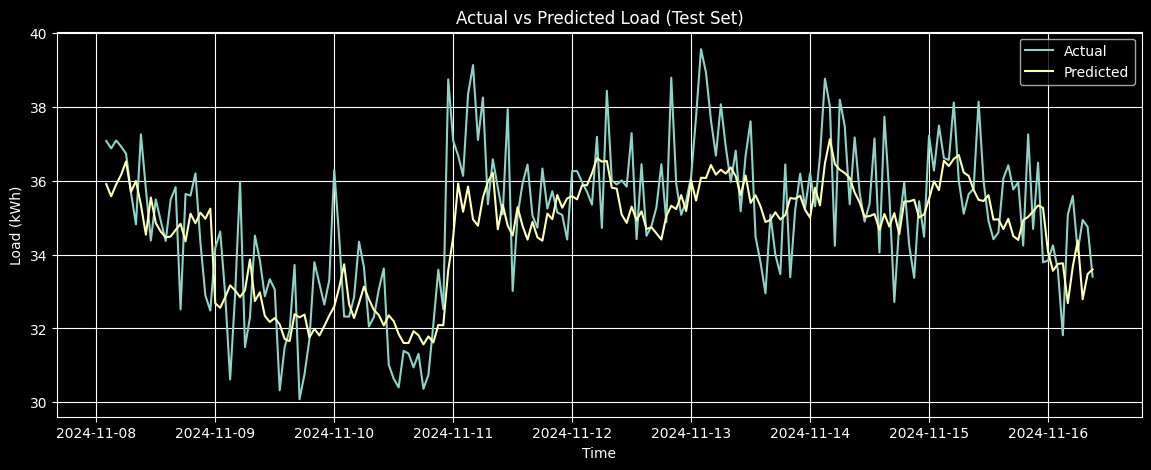

In [28]:
plt.figure(figsize=(14, 5))
plt.plot(y_test.index[:200], y_test.iloc[:200], label="Actual")
plt.plot(y_test.index[:200], test_pred[:200], label="Predicted")
plt.title("Actual vs Predicted Load (Test Set)")
plt.xlabel("Time")
plt.ylabel("Load (kWh)")
plt.legend()
plt.grid(True)
plt.show()

## Step 28: Compare the model to the baseline visually

In this step, the actual values, the baseline forecast, and the Random Forest forecast are plotted together.

This gives a direct visual comparison between the simple forecast and the machine learning forecast.

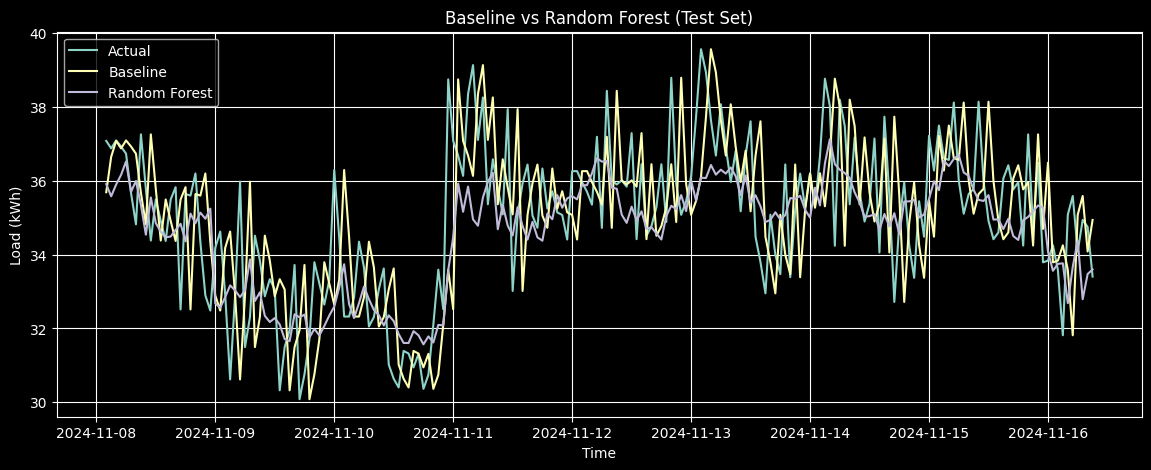

In [29]:
plt.figure(figsize=(14, 5))
plt.plot(y_test.index[:200], y_test.iloc[:200], label="Actual")
plt.plot(y_test.index[:200], baseline_test_pred.iloc[:200], label="Baseline")
plt.plot(y_test.index[:200], test_pred[:200], label="Random Forest")
plt.title("Baseline vs Random Forest (Test Set)")
plt.xlabel("Time")
plt.ylabel("Load (kWh)")
plt.legend()
plt.grid(True)
plt.show()

## Step 29: Inspect feature importance

In this step, the importance of each feature is calculated from the Random Forest model.

This helps explain which predictors influenced the model the most.

In [31]:
importances = pd.Series(model.feature_importances_, index=feature_columns)
importances = importances.sort_values(ascending=False)

display(importances)

lag_168             0.581599
rolling_mean_24     0.141147
lag_1               0.070128
rolling_mean_168    0.035624
hour                0.035157
temperature         0.019542
lag_24              0.017539
humidity            0.017145
hour_sin            0.015904
dow_sin             0.015466
wind_speed          0.015153
hour_cos            0.012984
day_of_week         0.010172
is_weekend          0.006105
month               0.004308
dow_cos             0.002026
dtype: float64

## Step 30: Visualize the most important features

In this step, the top feature importances are shown as a horizontal bar chart.

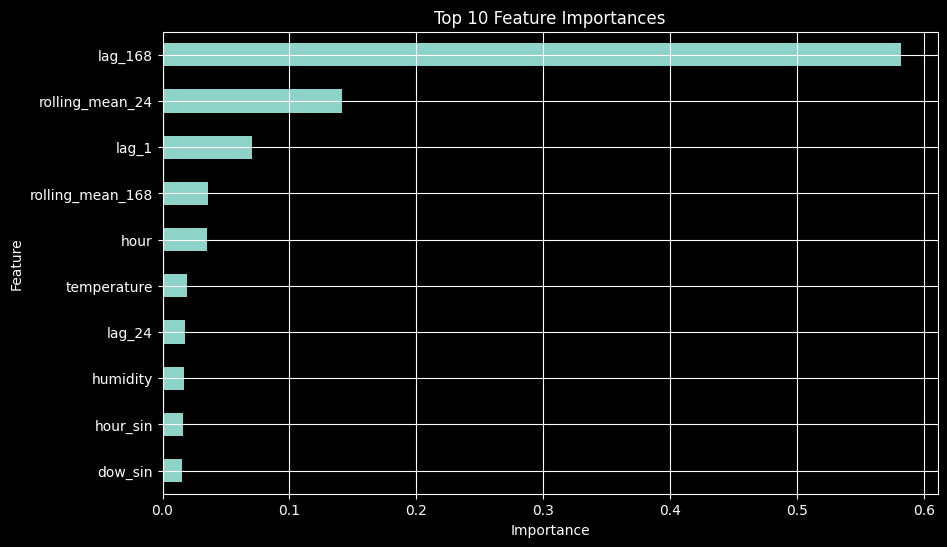

In [32]:
plt.figure(figsize=(10, 6))
importances.head(10).sort_values().plot(kind="barh")
plt.title("Top 10 Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.grid(True)
plt.show()

## Step 31: Calculate MAPE

In this step, MAPE is calculated as an additional accuracy metric.

MAPE expresses the error as a percentage, which is often easier to interpret.
A small constant is added to avoid division by zero.

In [35]:
def mean_absolute_percentage_error(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    epsilon = 1e-8
    return np.mean(np.abs((y_true - y_pred) / (y_true + epsilon))) * 100

mape_test = mean_absolute_percentage_error(y_test, test_pred)
print(f"Test MAPE: {mape_test:.2f}%")

Test MAPE: 3.42%


## Step 32: Save the forecasting results

In this final step, the actual values and predictions are saved to a CSV file.

This is useful for:
- later analysis
- reporting
- plotting in other tools

In [36]:
results_df = pd.DataFrame({
    "timestamp": y_test.index,
    "actual_load": y_test.values,
    "baseline_prediction": baseline_test_pred.values,
    "rf_prediction": test_pred
})

results_df.to_csv("load_forecasting_results.csv", index=False)
print("Results saved to load_forecasting_results.csv")
display(results_df.head())

Results saved to load_forecasting_results.csv


,timestamp,actual_load,baseline_prediction,rf_prediction
0,2024-11-08 02:00:00,37.076,35.686,35.906421
1,2024-11-08 03:00:00,36.873,36.646,35.576747
2,2024-11-08 04:00:00,37.088,37.076,35.894862
3,2024-11-08 05:00:00,36.925,36.873,36.158135
4,2024-11-08 06:00:00,36.729,37.088,36.518999
